# Final Project Step - Arjun

**Student Name:** Arjun Karthik

**Group:** 2

**Student ID:** 400364537

**CodaBench Username:** kartha4

***AI Citations:***

Please note that the core set up (i.e. imports) and the structure for the trainer was taken from Assignment 4. All AI prompts below were using ChatGPT:

1. Prompted to create my tokenize and metrics functions. 
2. Prompted to come up with trainer arguments
3. Prompted to create a heatmap of the confusion matrix for metrics visualization. 

Carbon emissions = 4.32g * Number of queries

3 queries

12.96g total

***Web citation:***

Used the following site to learn about the XLNet model and its implementation: 
https://huggingface.co/docs/transformers/en/model_doc/xlnet


In [9]:
# Install required packages (uncomment as needed)
# pip install transformers datasets scikit-learn torch evaluate accelerate
# !pip install sentencepiece  # needed for some tokenizers
# Core imports
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# HuggingFace
from datasets import load_dataset
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding, pipeline, XLNetTokenizer, XLNetForSequenceClassification, TrainingArguments, Trainer
import evaluate

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder

# PyTorch
import torch

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [5]:
#Added this code to mount my google drive since I ran colab from my local VSCode
from google.colab import drive # type: ignore

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#Load datasets from CSV files
train_dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Song Classification Files/genre_train.csv')
validation_dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Song Classification Files/genre_valid.csv')
test_dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Song Classification Files/test_dataset.csv')


In [4]:
print("Train dataset shape:", train_dataset.shape)
print(train_dataset.head())

print("Validation dataset shape:", validation_dataset.shape)
print(validation_dataset.head())

print("Test dataset shape:", test_dataset.shape)
print(test_dataset.head())


Train dataset shape: (30612, 3)
   lyric_id genre                                             lyrics
0     72800     p  [Timbaland]\nThere's a lot of people out there...
1     89665     p  Tom, get your plane right on time\nI know your...
2     20472     p  Yeah\nOh baby\nNow the word around town\n'roun...
3      1071     m  Close your eyes, what do you see?\nTakes a whi...
4     10734     m  Nobody move, Nobody gets hurt for all it's wor...
Validation dataset shape: (3827, 3)
   lyric_id genre                                             lyrics
0     13046     m  Fire and caffeine, a lot of nicotine\nI'm on a...
1     27780     p  Tell me how you want it baby I can be the one ...
2     47355     p  Singing, singing, singing\nOoh la la, he break...
3      5894     m  Hollywood we never going down....\n[Chorus]\nT...
4     66919     m  Ever since I was a young boy,\nI've played the...
Test dataset shape: (3827, 3)
   lyric_id genre                                             lyrics
0    

In [6]:
label_encoder = LabelEncoder()
train_dataset['genre'] = label_encoder.fit_transform(train_dataset['genre'])
validation_dataset['genre'] = label_encoder.transform(validation_dataset['genre'])
test_dataset['genre'] = label_encoder.transform(test_dataset['genre'])

train_hf = Dataset.from_pandas(train_dataset).rename_column("genre", "label")
valid_hf = Dataset.from_pandas(validation_dataset).rename_column("genre", "label")
test_hf = Dataset.from_pandas(test_dataset).rename_column("genre", "label")

tokenizer = XLNetTokenizer.from_pretrained('xlnet-base-cased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


In [9]:
def tokenize_function(examples):
    return tokenizer(
        examples['lyrics'], 
        padding="max_length", 
        truncation=True, 
        max_length=128
    )

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='macro')
    return {'accuracy': acc, 'f1': f1}

In [10]:
train_tokenized = train_hf.map(tokenize_function, batched=True)
valid_tokenized = valid_hf.map(tokenize_function, batched=True)
test_tokenized = test_hf.map(tokenize_function, batched=True)

num_genres = len(label_encoder.classes_) 
model = XLNetForSequenceClassification.from_pretrained('xlnet-base-cased', num_labels=num_genres)

training_args = TrainingArguments(
    output_dir='./xlnet-song-classifier',
    num_train_epochs=3,               
    per_device_train_batch_size=8,      
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,      
    eval_strategy="epoch",     
    save_strategy="epoch",
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=valid_tokenized,
    compute_metrics=compute_metrics,
)

Map:   0%|          | 0/30612 [00:00<?, ? examples/s]

Map:   0%|          | 0/3827 [00:00<?, ? examples/s]

Map:   0%|          | 0/3827 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

XLNetForSequenceClassification LOAD REPORT from: xlnet-base-cased
Key                             | Status     | 
--------------------------------+------------+-
lm_loss.weight                  | UNEXPECTED | 
lm_loss.bias                    | UNEXPECTED | 
logits_proj.weight              | MISSING    | 
sequence_summary.summary.bias   | MISSING    | 
sequence_summary.summary.weight | MISSING    | 
logits_proj.bias                | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:
print("Starting training...")
trainer.train()

print("Evaluating on test dataset...")
test_results = trainer.evaluate(test_tokenized)
print(test_results)

Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.787484,0.377606,0.833290,0.832801
2,0.616475,0.365149,0.853933,0.853929
3,0.425732,0.418834,0.858375,0.858371


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Evaluating on test dataset...


{'eval_loss': 0.43586885929107666, 'eval_accuracy': 0.852103475307029, 'eval_f1': 0.8521012031924173, 'eval_runtime': 34.995, 'eval_samples_per_second': 109.358, 'eval_steps_per_second': 13.688, 'epoch': 3.0}


In [12]:
predictions, labels, _ = trainer.predict(test_tokenized)
predicted_classes = np.argmax(predictions, axis=-1)
target_names = label_encoder.classes_

report = classification_report(
    labels, 
    predicted_classes, 
    target_names=target_names
)

print("\n--- Final Classification Report ---")
print(report)


--- Final Classification Report ---
              precision    recall  f1-score   support

           m       0.86      0.85      0.85      1914
           p       0.85      0.86      0.85      1913

    accuracy                           0.85      3827
   macro avg       0.85      0.85      0.85      3827
weighted avg       0.85      0.85      0.85      3827



In [15]:
predicted_classes = np.argmax(predictions, axis=-1)
predicted_genre_names = label_encoder.inverse_transform(predicted_classes)

predictions_df = pd.DataFrame({
    'lyric_id': test_dataset['lyric_id'],
    'predicted_genre': predicted_genre_names
})

predictions_df.to_csv('/content/drive/MyDrive/Colab Notebooks/Song Classification Files/xlnet_predictions.csv', index=False)

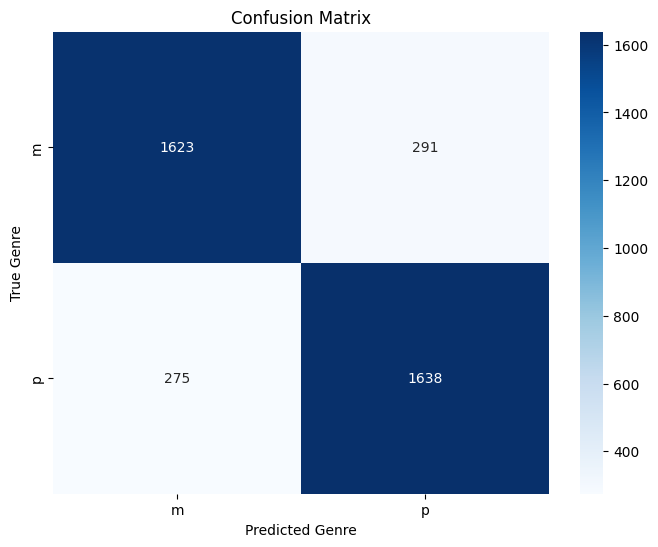

In [14]:
correct_labels = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Song Classification Files/test_labels.csv')
predicted_labels = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Song Classification Files/xlnet_predictions.csv')

merged_df = pd.merge(correct_labels, predicted_labels, on='lyric_id')

labels = sorted(merged_df['genre'].unique())
cm = confusion_matrix(merged_df['genre'], merged_df['predicted_genre'], labels=labels)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    xticklabels=labels, 
    yticklabels=labels,
    cmap='Blues' 
)

plt.xlabel('Predicted Genre')
plt.ylabel('True Genre')
plt.title('Confusion Matrix')
plt.show()